# Pengelompokan Pelanggan Berdasarkan Perilaku Transaksi Menggunakan Fitur Autoencoder dan K-Means
**Kelompok:** lebih oke mana JavaScript atau VSCode bang? 

**Anggota:** 
1. Muhammad Fairuz Ananta           (5025251046)
2. I Komang Bagus Alvero Wisnawa    (5025251088)
3. Medina Kusuma Prianda            (5025251240)
4. Muhammad Fardan Hafidz           (5054251021)

**Mata Acara:** Lab Based Education KCV — Final Project (Presentasi 25 Sep 2026)

**Aturan teknis yang dipenuhi notebook ini:**
- Model penentu klaster akhir = **ML klasik** (K-Means utama; Hierarchical & DBSCAN sebagai pembanding). Deep Learning **hanya** sebagai *feature extractor / preprocessing* (MLP Autoencoder → bottleneck embedding), bukan penentu klaster.
- Minimal **3 skenario eksperimen** (Pola 2 variasi fitur + lampiran Pola 1 antar-algoritma = Hybrid).
- Data dipisah **train/test** (`data_train.csv` 37.500 / `data_test.csv` 12.500); semua metrik evaluasi dihitung di **data uji**.
- Model **pre-fitted** dan disimpan (`artifacts/`) + `demo_input.csv` sehingga demo tinggal *load*, tanpa training ulang.
- Alur notebook: **A. Persiapan & Dataset → B. Parameter Optimal → C. 3 Skenario → D. Evaluasi → E. Visualisasi/Profiling/Demo**.
- Flowchart arsitektur: `Raw CSV → Imputasi + One-Hot + StandardScaler → [ (a) Scaled | (b) PCA | (c) Autoencoder embedding ] → K-Means (+ pembanding Agglomerative/DBSCAN) → Evaluasi & Profiling`.


In [2]:
import os, random, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn import set_config
from sklearn.neighbors import NearestNeighbors
set_config(working_memory=256)  # chunk jarak kecil agar silhouette 37k muat RAM; hasil eksak sama
from scipy.cluster.hierarchy import dendrogram, linkage
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)
warnings.filterwarnings("ignore"); sns.set(style="whitegrid")
ART = "artifacts"; os.makedirs(ART, exist_ok=True)
print("numpy", np.__version__, "| pandas", pd.__version__, "| torch", torch.__version__)
import sklearn, scipy; print("sklearn", sklearn.__version__, "| scipy", scipy.__version__)

numpy 2.2.6 | pandas 2.3.3 | torch 2.14.0+cpu
sklearn 1.7.2 | scipy 1.15.3


## Bagian A — Persiapan Lingkungan & Dataset
1. Import & seed (cell di atas, `random_state=42` agar konsisten).
2. Load `data_train.csv` / `data_test.csv`, EDA missing & distribusi.
3. Preprocessing: imputasi median/modus + One-Hot + **StandardScaler** (wajib untuk algoritma berbasis jarak).
4. PCA (pendukung + visualisasi 2D) dan **MLP Autoencoder** sebagai DL feature extractor (bottleneck disimpan dulu sebagai array/file).


In [3]:
train = pd.read_csv("data_train.csv"); test = pd.read_csv("data_test.csv")
print("train:", train.shape, "| test:", test.shape)
print("\nKolom:", list(train.columns))
print("\n--- Missing train (%) ---\n", (train.isna().sum()/len(train)*100).round(2).sort_values(ascending=False).to_string())
print("\n--- Missing test (%) ---\n", (test.isna().sum()/len(test)*100).round(2).sort_values(ascending=False).to_string())
print("\n--- Deskriptif numerik (train) ---"); display(train.describe().round(2).T)
print("\n--- payment_channel ---\n", train["payment_channel"].value_counts(dropna=False).to_string())
print("\n--- market_area ---\n", train["market_area"].value_counts(dropna=False).to_string())

train: (37500, 13) | test: (12500, 13)

Kolom: ['record_id', 'age_years', 'income_value', 'tenure_months', 'monthly_spend', 'purchase_rate', 'order_value', 'promo_usage_rate', 'return_rate', 'browse_minutes', 'support_contacts', 'payment_channel', 'market_area']

--- Missing train (%) ---
 browse_minutes      8.03
income_value        6.18
promo_usage_rate    5.06
monthly_spend       4.99
return_rate         4.97
purchase_rate       4.03
support_contacts    4.02
record_id           0.00
age_years           0.00
tenure_months       0.00
order_value         0.00
payment_channel     0.00
market_area         0.00

--- Missing test (%) ---
 browse_minutes      7.38
income_value        6.05
promo_usage_rate    5.21
monthly_spend       5.19
return_rate         4.98
support_contacts    3.83
purchase_rate       3.75
record_id           0.00
age_years           0.00
tenure_months       0.00
order_value         0.00
payment_channel     0.00
market_area         0.00

--- Deskriptif numerik (train) 

,count,mean,std,min,25%,50%,75%,max
age_years,37500.0,44.02,15.24,18.0,31.00,44.00,57.00,70.00
income_value,35181.0,36420.50,47022.77,0.0,152.16,12676.84,62953.72,495118.02
tenure_months,37500.0,26.24,31.17,1.0,1.00,1.00,72.00,72.00
monthly_spend,35629.0,263.79,375.50,0.0,0.76,68.71,417.99,3691.32
purchase_rate,35990.0,5.09,7.07,0.0,0.01,0.59,9.83,73.21
order_value,37500.0,96.38,90.27,0.0,27.13,80.50,140.18,1343.59
promo_usage_rate,35602.0,0.34,0.20,0.0,0.20,0.34,0.48,1.00
return_rate,35636.0,0.16,0.11,0.0,0.08,0.14,0.23,0.85
browse_minutes,34488.0,60.28,46.88,0.0,24.60,52.95,85.40,431.16
support_contacts,35991.0,1.58,1.30,0.0,1.00,1.00,2.00,9.00



--- payment_channel ---
 payment_channel
Channel_A    18752
Channel_C    11170
Channel_B     7578

--- market_area ---
 market_area
Area_A    18657
Area_B    11393
Area_C     7450


### EDA Lengkap: isi kolom, contoh nilai, distribusi, korelasi & temuan receh
Cell-cell berikut menjawab: kolom apa saja isinya, contoh nilainya seperti apa,
bagaimana sebaran tiap fitur, fitur mana yang berkorelasi, dan pola apa yang
menjelaskan kenapa klaster akhirnya berjumlah 2.


In [4]:
NUM = ["age_years","income_value","tenure_months","monthly_spend","purchase_rate","order_value","promo_usage_rate","return_rate","browse_minutes","support_contacts"]
CAT = ["payment_channel","market_area"]
print("Shape train:", train.shape, "| Shape test:", test.shape)
print("\n--- dtypes & memori ---"); print(train.dtypes.to_string())
print("\nMemori train: %.2f MB" % (train.memory_usage(deep=True).sum()/1024**2))
print("\nrecord_id unik:", train["record_id"].nunique(), "| duplikat:", int(train["record_id"].duplicated().sum()))
print("\n--- 10 baris pertama (contoh nilai tiap kolom) ---"); display(train.head(10))
print("--- 3 baris terakhir ---"); display(train.tail(3))
print("--- 5 baris acak (seed 42) ---"); display(train.sample(5, random_state=42))

Shape train: (37500, 13) | Shape test: (12500, 13)

--- dtypes & memori ---
record_id            object
age_years             int64
income_value        float64
tenure_months         int64
monthly_spend       float64
purchase_rate       float64
order_value         float64
promo_usage_rate    float64
return_rate         float64
browse_minutes      float64
support_contacts    float64
payment_channel      object
market_area          object

Memori train: 9.73 MB



record_id unik: 37500 | duplikat: 0

--- 10 baris pertama (contoh nilai tiap kolom) ---


,record_id,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts,payment_channel,market_area
0,R47188,34,604.31,1,0.00,0.00,141.31,0.49,0.24,0.78,3.0,Channel_B,Area_A
1,R28234,21,14200.45,56,158.44,1.71,68.90,0.52,0.63,26.99,2.0,Channel_A,Area_A
2,R41083,70,96781.53,72,1184.50,20.20,0.00,0.28,0.13,73.89,0.0,Channel_C,Area_B
3,R00611,22,92746.14,72,NaN,12.64,1.13,0.30,0.08,52.71,1.0,Channel_A,Area_A
4,R31314,49,68426.29,72,465.48,11.26,10.21,0.22,0.48,68.57,NaN,Channel_A,Area_C
5,R19035,24,114201.58,72,496.11,9.75,17.35,0.20,NaN,65.74,2.0,Channel_A,Area_A
6,R19444,63,NaN,72,1026.02,20.65,0.00,0.00,0.16,130.17,2.0,Channel_A,Area_B
7,R27932,19,74656.06,72,582.39,11.54,5.61,0.32,0.06,46.50,3.0,Channel_A,Area_A
8,R36573,70,93520.55,72,374.17,14.25,1.23,0.00,0.06,28.76,0.0,Channel_B,Area_C
9,R16918,41,25472.29,21,127.19,3.27,62.76,0.25,0.15,85.09,1.0,Channel_A,Area_A


--- 3 baris terakhir ---


,record_id,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts,payment_channel,market_area
37497,R06422,54,0.00,1,0.92,0.06,151.04,NaN,0.25,0.00,0.0,Channel_C,Area_C
37498,R27367,34,202.62,1,0.00,0.13,149.23,0.75,0.05,52.02,2.0,Channel_A,Area_B
37499,R42697,25,54963.49,69,481.52,19.40,0.00,0.14,0.19,64.06,2.0,Channel_C,Area_B


--- 5 baris acak (seed 42) ---


,record_id,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts,payment_channel,market_area
24985,R33569,55,0.00,1,0.00,0.03,176.83,0.37,0.25,5.79,1.0,Channel_B,Area_A
19125,R14903,39,101983.40,72,1166.14,29.17,0.00,0.00,0.07,84.56,2.0,Channel_A,Area_A
3077,R04474,25,422.83,1,6.76,0.00,105.84,0.50,0.11,7.61,1.0,Channel_A,Area_B
24526,R43805,42,43897.49,72,360.65,10.26,0.00,0.18,0.00,115.93,2.0,Channel_B,Area_A
32428,R27621,63,0.00,1,1100.56,0.05,312.27,0.39,0.19,43.75,0.0,Channel_A,Area_A


In [5]:
desc = train[NUM+CAT].describe(include="all").round(2).T
desc["skew"] = train[NUM].skew(numeric_only=True).round(2)
desc["kurt"] = train[NUM].kurt(numeric_only=True).round(2)
display(desc)
print("\n--- Jumlah nilai NOL per kolom numerik (0 bisa berarti tidak aktif!) ---")
print((train[NUM] == 0).sum().to_string())
print("\n--- Top-5 monthly_spend terbesar ---"); display(train.nlargest(5, "monthly_spend")[["record_id"]+NUM].round(2))
print("--- Pelanggan termuda vs tertua ---")
print(train.loc[[train["age_years"].idxmin(), train["age_years"].idxmax()], ["record_id","age_years","tenure_months","monthly_spend"]].to_string(index=False))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,skew,kurt
age_years,37500.0,NaN,NaN,NaN,44.02,15.24,18.0,31.0,44.0,57.0,70.0,0.01,-1.19
income_value,35181.0,NaN,NaN,NaN,36420.5,47022.77,0.0,152.16,12676.84,62953.72,495118.02,1.50,3.07
tenure_months,37500.0,NaN,NaN,NaN,26.24,31.17,1.0,1.0,1.0,72.0,72.0,0.62,-1.46
monthly_spend,35629.0,NaN,NaN,NaN,263.79,375.5,0.0,0.76,68.71,417.99,3691.32,1.74,3.10
purchase_rate,35990.0,NaN,NaN,NaN,5.09,7.07,0.0,0.01,0.59,9.83,73.21,1.36,1.24
order_value,37500.0,NaN,NaN,NaN,96.38,90.27,0.0,27.13,80.5,140.18,1343.59,1.76,6.63
promo_usage_rate,35602.0,NaN,NaN,NaN,0.34,0.2,0.0,0.2,0.34,0.48,1.0,0.24,-0.36
return_rate,35636.0,NaN,NaN,NaN,0.16,0.11,0.0,0.08,0.14,0.23,0.85,0.98,1.03
browse_minutes,34488.0,NaN,NaN,NaN,60.28,46.88,0.0,24.6,52.95,85.4,431.16,1.15,2.20
support_contacts,35991.0,NaN,NaN,NaN,1.58,1.3,0.0,1.0,1.0,2.0,9.0,0.80,0.56



--- Jumlah nilai NOL per kolom numerik (0 bisa berarti tidak aktif!) ---
age_years              0
income_value        7332
tenure_months          0
monthly_spend       7804
purchase_rate       8905
order_value         2536
promo_usage_rate    1874
return_rate         1787
browse_minutes      1231
support_contacts    8080

--- Top-5 monthly_spend terbesar ---


,record_id,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts
25416,R25093,18,108442.83,72,3691.32,20.17,270.69,0.10,0.01,119.48,1.0
33262,R24209,55,114116.82,72,3688.62,16.50,377.18,0.15,0.12,105.13,0.0
32230,R38655,70,103223.57,72,3590.00,16.33,466.43,0.01,0.00,121.20,1.0
9219,R19807,67,165956.97,72,3003.59,23.89,123.56,0.15,0.13,77.96,1.0
24148,R15031,20,136304.63,72,2978.28,20.15,41.80,0.23,0.00,88.89,0.0


--- Pelanggan termuda vs tertua ---
record_id  age_years  tenure_months  monthly_spend
   R37298         18              1           3.41
   R41083         70             72        1184.50


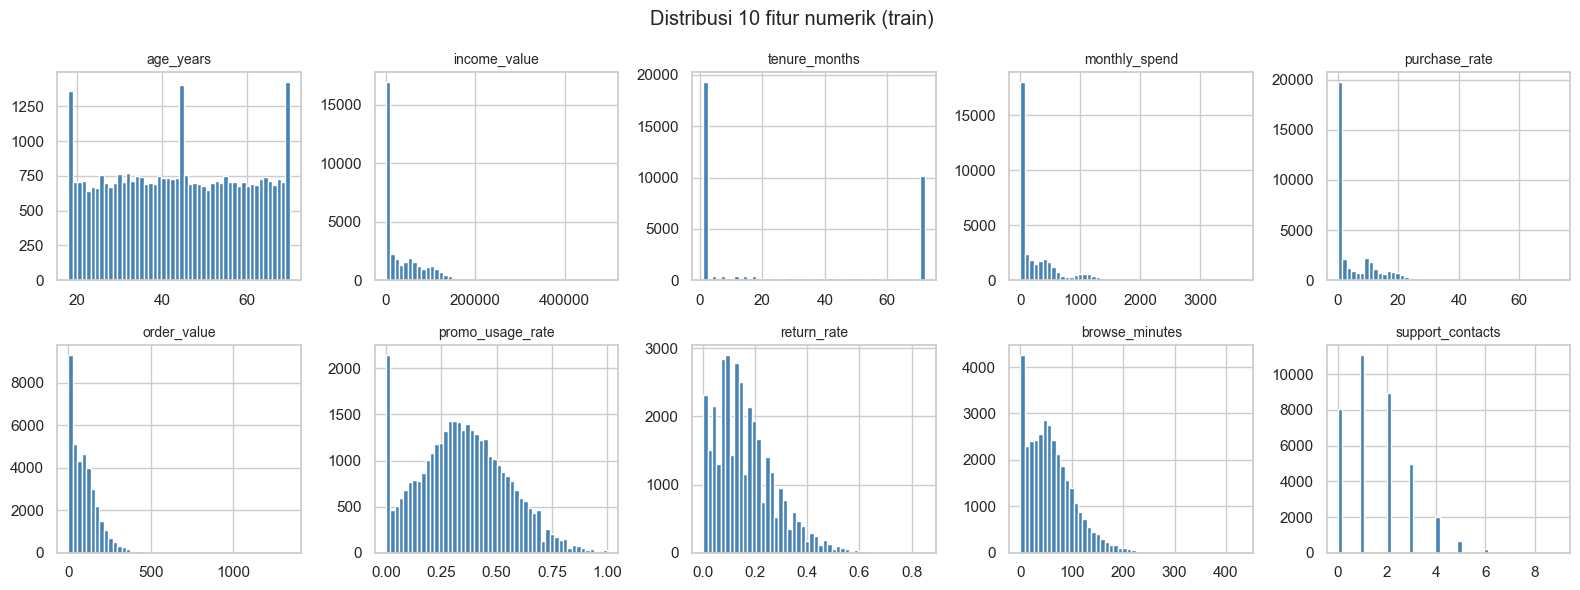

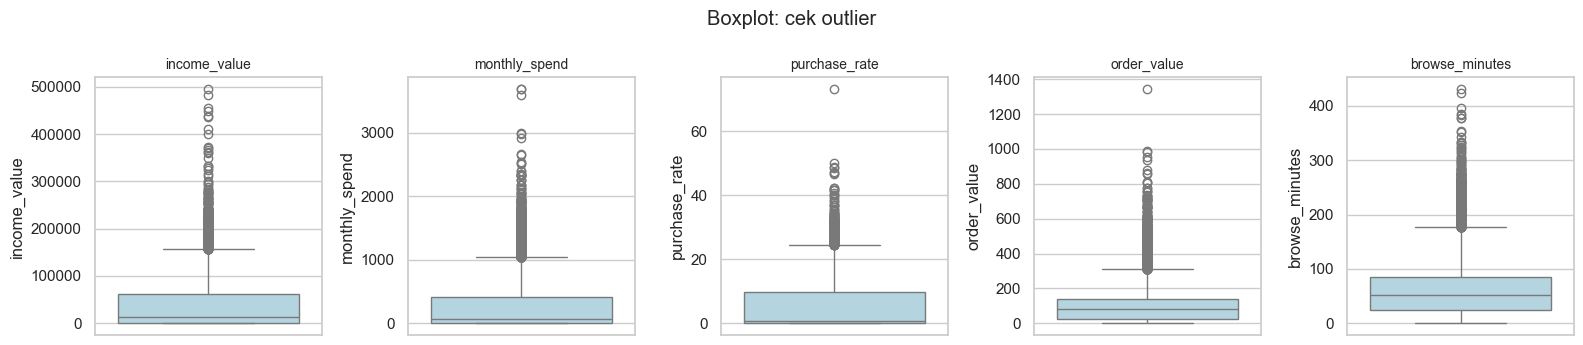

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16,6))
for a, c in zip(axes.flat, NUM):
    train[c].hist(bins=50, ax=a, color="steelblue"); a.set_title(c, fontsize=10)
plt.suptitle("Distribusi 10 fitur numerik (train)"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 5, figsize=(16,3.5))
for a, c in zip(axes.flat, ["income_value","monthly_spend","purchase_rate","order_value","browse_minutes"]):
    sns.boxplot(data=train, y=c, ax=a, color="lightblue"); a.set_title(c, fontsize=10)
plt.suptitle("Boxplot: cek outlier"); plt.tight_layout(); plt.show()

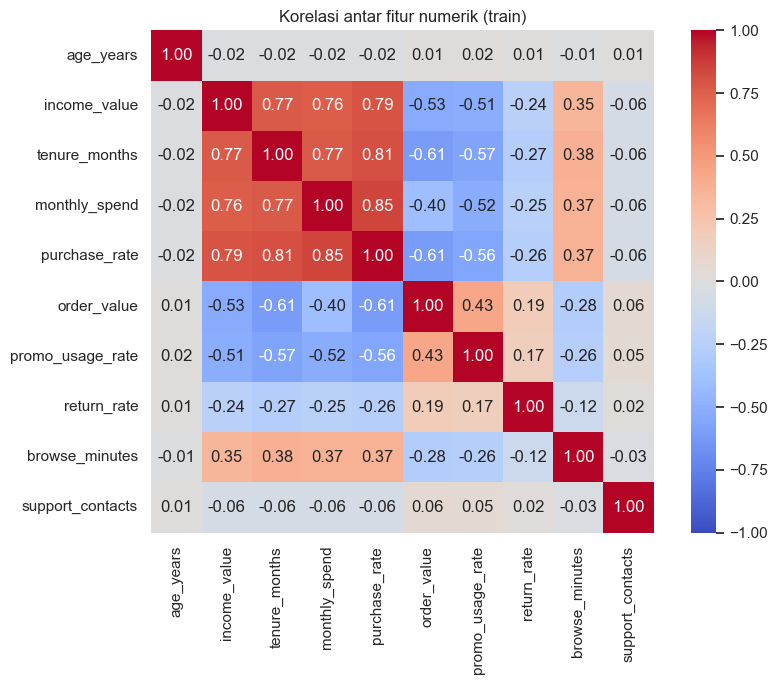

Pasangan korelasi terkuat (|r|):
purchase_rate  monthly_spend    0.85
monthly_spend  purchase_rate    0.85
tenure_months  purchase_rate    0.81
purchase_rate  tenure_months    0.81
               income_value     0.79
income_value   purchase_rate    0.79
               tenure_months    0.77
tenure_months  income_value     0.77


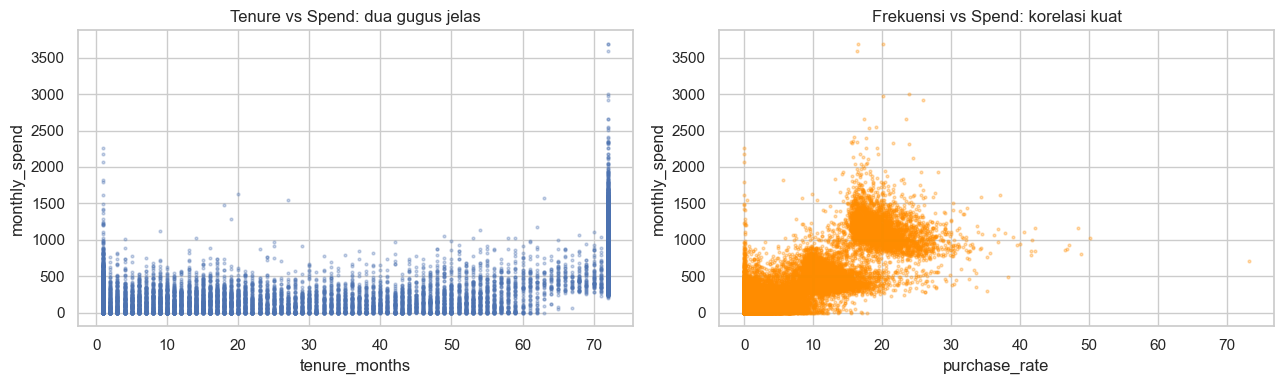

In [7]:
corr = train[NUM].corr().round(2)
plt.figure(figsize=(9,7)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Korelasi antar fitur numerik (train)"); plt.tight_layout(); plt.show()
print("Pasangan korelasi terkuat (|r|):")
cs = corr.abs().where(~np.eye(len(corr), dtype=bool)).stack().sort_values(ascending=False)
print(cs.head(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].scatter(train["tenure_months"], train["monthly_spend"], s=4, alpha=0.3); axes[0].set_xlabel("tenure_months"); axes[0].set_ylabel("monthly_spend"); axes[0].set_title("Tenure vs Spend: dua gugus jelas")
axes[1].scatter(train["purchase_rate"], train["monthly_spend"], s=4, alpha=0.3, color="darkorange"); axes[1].set_xlabel("purchase_rate"); axes[1].set_ylabel("monthly_spend"); axes[1].set_title("Frekuensi vs Spend: korelasi kuat")
plt.tight_layout(); plt.show()

--- Crosstab channel x area ---


market_area,Area_A,Area_B,Area_C
payment_channel,,,
Channel_A,9396,5693,3663
Channel_B,3729,2329,1520
Channel_C,5532,3371,2267



--- Rata-rata spend & tenure per channel/area (apakah membedakan?) ---


,monthly_spend,tenure_months,purchase_rate
payment_channel,,,
Channel_A,261.57,26.03,5.07
Channel_B,264.21,26.22,5.13
Channel_C,267.26,26.59,5.09


,monthly_spend,tenure_months,purchase_rate
market_area,,,
Area_A,278.56,27.56,5.28
Area_B,257.03,25.85,5.02
Area_C,236.94,23.50,4.70



--- Jumlah & rata-rata spend per kelompok umur (EDA receh) ---


,n,mean_spend,mean_tenure
age_bin,,,
18-30,8356,265.70,26.70
31-45,10859,276.46,27.15
46-60,10487,263.97,26.16
61-70,7099,242.04,24.48


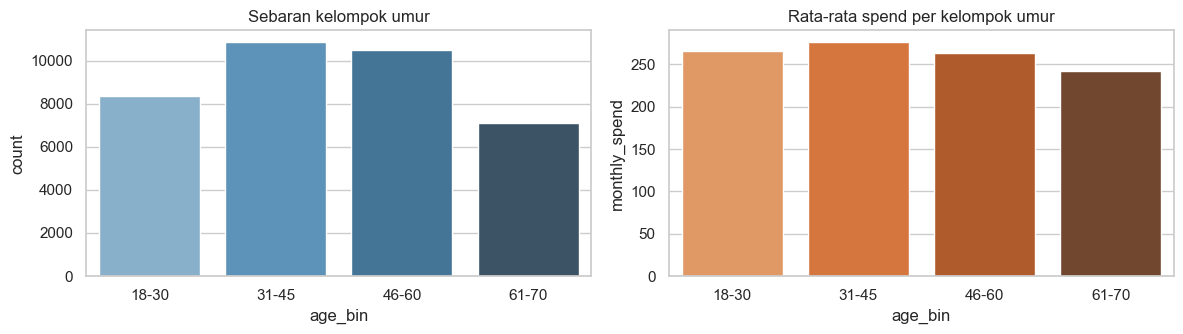

In [8]:
print("--- Crosstab channel x area ---"); display(pd.crosstab(train["payment_channel"], train["market_area"]))
print("\n--- Rata-rata spend & tenure per channel/area (apakah membedakan?) ---")
display(train.groupby("payment_channel")[["monthly_spend","tenure_months","purchase_rate"]].mean().round(2))
display(train.groupby("market_area")[["monthly_spend","tenure_months","purchase_rate"]].mean().round(2))

train["age_bin"] = pd.cut(train["age_years"], [18,30,45,60,70], labels=["18-30","31-45","46-60","61-70"])
print("\n--- Jumlah & rata-rata spend per kelompok umur (EDA receh) ---")
display(train.groupby("age_bin", observed=True).agg(n=("record_id","count"), mean_spend=("monthly_spend","mean"), mean_tenure=("tenure_months","mean")).round(2))
fig, axes = plt.subplots(1, 2, figsize=(12,3.5))
sns.countplot(data=train, x="age_bin", ax=axes[0], palette="Blues_d"); axes[0].set_title("Sebaran kelompok umur")
sns.barplot(data=train, x="age_bin", y="monthly_spend", ax=axes[1], palette="Oranges_d", errorbar=None); axes[1].set_title("Rata-rata spend per kelompok umur")
plt.tight_layout(); plt.show()
train.drop(columns="age_bin", inplace=True)

In [9]:
t = train["tenure_months"]
print("Bukti tenure BIMODAL (penjelas k=2):")
print(f"  tenure==1 bulan : {(t==1).mean()*100:.1f}% pelanggan")
print(f"  tenure==72 bulan: {(t==72).mean()*100:.1f}% pelanggan")
print(f"  tenure<=8 bulan : {(t<=8).mean()*100:.1f}%  vs  tenure>=50: {(t>=50).mean()*100:.1f}%")
print(f"  tenure di 2-49  : {((t>8)&(t<50)).mean()*100:.1f}% (jurang di tengah!)")
print("\nPola NOL (pelanggan tidak aktif di aspek tsb):")
print(f"  income==0 : {(train['income_value']==0).mean()*100:.1f}% | monthly_spend==0 : {(train['monthly_spend']==0).mean()*100:.1f}%")
print(f"  purchase_rate==0 : {(train['purchase_rate']==0).mean()*100:.1f}% | order_value==0 : {(train['order_value']==0).mean()*100:.1f}%")
print("\nRata-rata spend: tenure==1 → %.1f vs tenure==72 → %.1f" % (
    train.loc[t==1,"monthly_spend"].mean(), train.loc[t==72,"monthly_spend"].mean()))

Bukti tenure BIMODAL (penjelas k=2):
  tenure==1 bulan : 50.9% pelanggan
  tenure==72 bulan: 27.0% pelanggan
  tenure<=8 bulan : 54.5%  vs  tenure>=50: 31.1%
  tenure di 2-49  : 14.3% (jurang di tengah!)

Pola NOL (pelanggan tidak aktif di aspek tsb):
  income==0 : 19.6% | monthly_spend==0 : 20.8%
  purchase_rate==0 : 23.7% | order_value==0 : 6.8%

Rata-rata spend: tenure==1 → 40.3 vs tenure==72 → 748.8


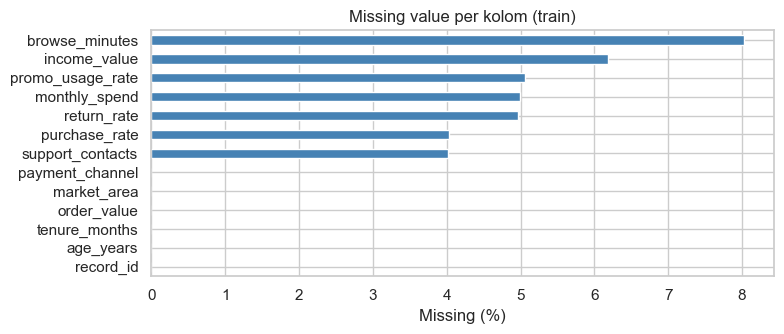

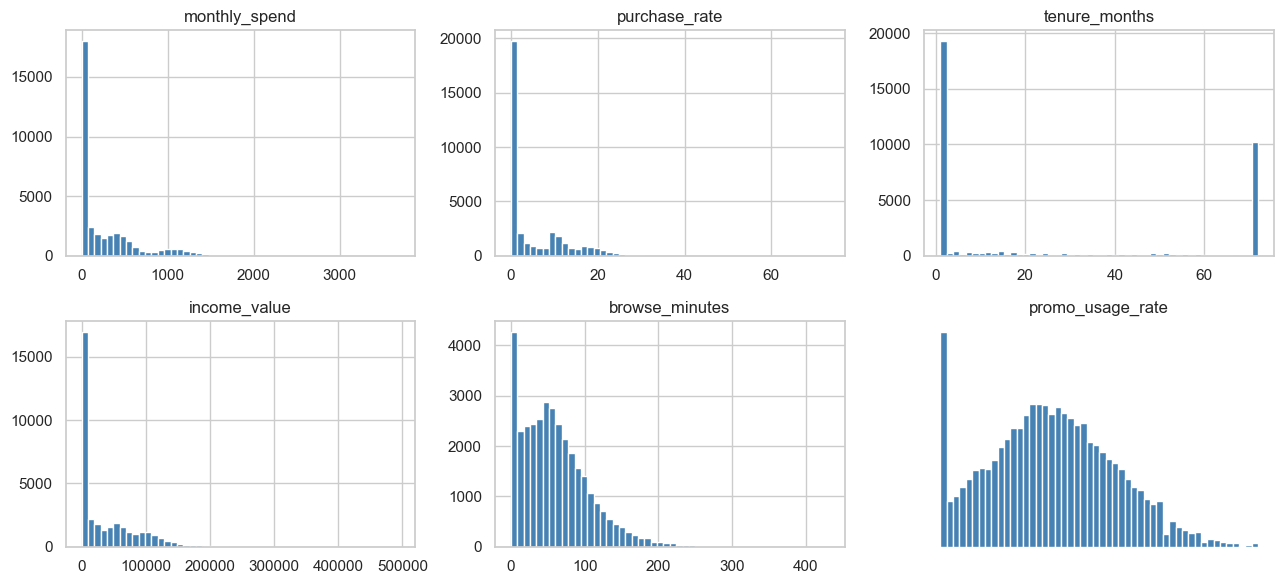

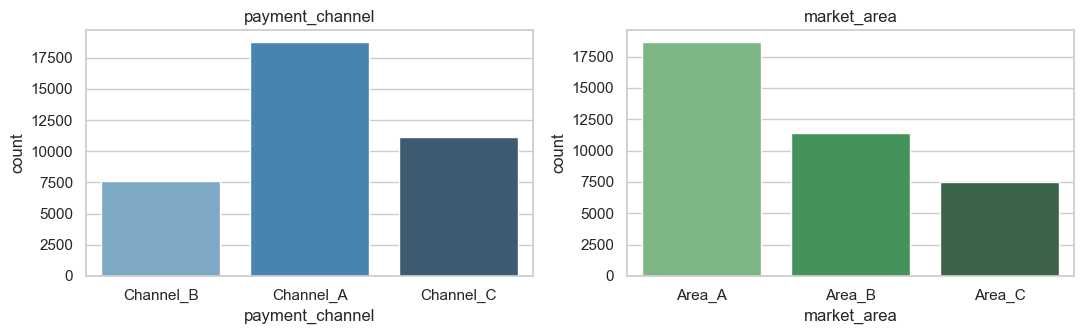

In [10]:
NUM = ["age_years","income_value","tenure_months","monthly_spend","purchase_rate","order_value","promo_usage_rate","return_rate","browse_minutes","support_contacts"]
CAT = ["payment_channel","market_area"]

fig, ax = plt.subplots(figsize=(8,3.5))
(train.isna().sum()/len(train)*100).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Missing (%)"); ax.set_title("Missing value per kolom (train)"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13,6))
for a, c in zip(axes.flat, ["monthly_spend","purchase_rate","tenure_months","income_value","browse_minutes","promo_usage_rate"]):
    train[c].hist(bins=50, ax=a, color="steelblue"); a.set_title(c)
axes.flat[-1].axis("off"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11,3.5))
sns.countplot(data=train, x="payment_channel", ax=axes[0], palette="Blues_d"); axes[0].set_title("payment_channel")
sns.countplot(data=train, x="market_area", ax=axes[1], palette="Greens_d"); axes[1].set_title("market_area")
plt.tight_layout(); plt.show()

In [11]:
num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
pre = ColumnTransformer([("num", num_pipe, NUM), ("cat", cat_pipe, CAT)])

X_train_scaled = pre.fit_transform(train[NUM+CAT])
X_test_scaled  = pre.transform(test[NUM+CAT])
print("X_train_scaled:", X_train_scaled.shape, "| X_test_scaled:", X_test_scaled.shape)
joblib.dump(pre, f"{ART}/preprocessor.joblib")
print("Disimpan: artifacts/preprocessor.joblib (fit hanya di TRAIN, dipakai transform test/demo)")

X_train_scaled: (37500, 16) | X_test_scaled: (12500, 16)
Disimpan: artifacts/preprocessor.joblib (fit hanya di TRAIN, dipakai transform test/demo)


MENTAH                                          SCALED (z-score)  \
  income_value monthly_spend promo_usage_rate age_years     income_value   
0       604.31          0.00             0.49        34           -0.748   
1     14200.45        158.44             0.52        21           -0.452   
2     96781.53       1184.50             0.28        70            1.347   
3     92746.14           NaN             0.30        22            1.259   
4     68426.29        465.48             0.22        49            0.729   

                                            
  monthly_spend promo_usage_rate age_years  
0        -0.690            0.755    -0.658  
1        -0.260            0.910    -1.511  
2         2.525           -0.327     1.704  
3        -0.503           -0.224    -1.445  
4         0.574           -0.636     0.327

Cara baca: monthly_spend 1184.5 menjadi 2.45; promo_usage_rate 0.28 menjadi -0.31.
Satuan ratusan ribu vs 0-1 kini sebanding sehingga K-Means tidak didominasi 1 fitur.


,mean_mentah,std_mentah,mean_scaled,std_scaled
age_years,44.0228,15.2411,-0.0,1.0
income_value,36420.5029,47022.7673,-0.0,1.0
tenure_months,26.2365,31.1661,-0.0,1.0
monthly_spend,263.7912,375.5018,-0.0,1.0
purchase_rate,5.0874,7.0651,0.0,1.0
order_value,96.3820,90.2741,-0.0,1.0
promo_usage_rate,0.3436,0.1992,0.0,1.0
return_rate,0.1615,0.1150,-0.0,1.0
browse_minutes,60.2804,46.8777,-0.0,1.0
support_contacts,1.5764,1.2951,0.0,1.0


Bukti matematis: sesudah scaling, mean ~ 0 dan std = 1 untuk semua fitur.


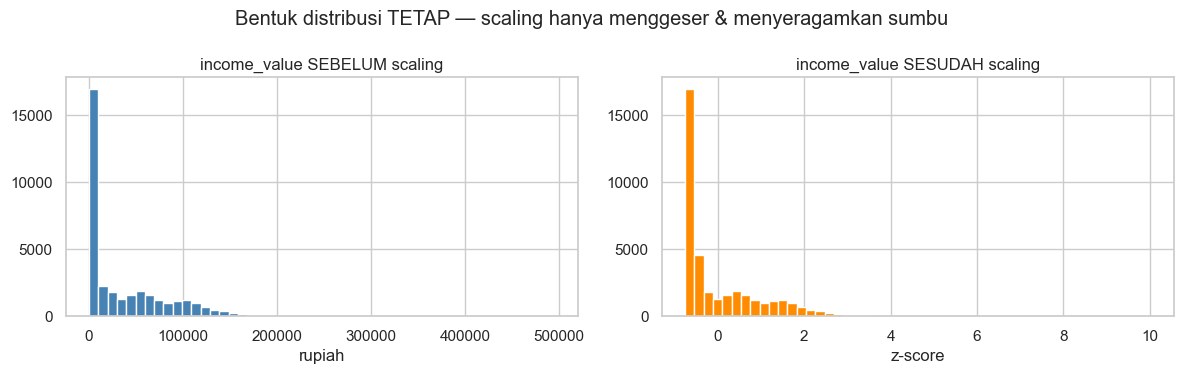

In [12]:
# BEFORE-AFTER SCALING: 5 baris yang sama (mentah vs scaled) + bukti statistik + histogram
SHOW = ["income_value", "monthly_spend", "promo_usage_rate", "age_years"]  # 2 skala besar + 2 skala kecil
scaled_num = pd.DataFrame(X_train_scaled[:, :len(NUM)], columns=NUM)
raw5 = train[SHOW].head(5)
scl5 = scaled_num[SHOW].head(5).round(3)
display(pd.concat({"MENTAH": raw5, "SCALED (z-score)": scl5}, axis=1))
print("Cara baca: monthly_spend 1184.5 menjadi 2.45; promo_usage_rate 0.28 menjadi -0.31.")
print("Satuan ratusan ribu vs 0-1 kini sebanding sehingga K-Means tidak didominasi 1 fitur.")

cmp = pd.DataFrame({"mean_mentah": train[NUM].mean(), "std_mentah": train[NUM].std(),
                    "mean_scaled": scaled_num.mean(), "std_scaled": scaled_num.std()}).round(4)
display(cmp)
print("Bukti matematis: sesudah scaling, mean ~ 0 dan std = 1 untuk semua fitur.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
train["income_value"].hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("income_value SEBELUM scaling"); axes[0].set_xlabel("rupiah")
axes[1].hist(scaled_num["income_value"], bins=50, color="darkorange")
axes[1].set_title("income_value SESUDAH scaling"); axes[1].set_xlabel("z-score")
plt.suptitle("Bentuk distribusi TETAP — scaling hanya menggeser & menyeragamkan sumbu")
plt.tight_layout(); plt.show()

### Dimensionality Reduction & DL Feature Extractor
- **PCA**: untuk reduksi dimensi (Skenario 2) dan visualisasi 2D. Karena fitur one-hot + scaling total 16 dimensi, PCA-8 menjaga sebagian besar varians.
- **MLP Autoencoder (PyTorch)** — peran DL sesuai aturan: *hanya* mengekstrak **embedding bottleneck 8-dim** (Skenario 3). Klaster akhir tetap ditentukan K-Means klasik.


Explained variance ratio (8): [0.3883 0.0891 0.0883 0.0812 0.0724 0.0582 0.0526 0.0347]
Kumulatif 8 komponen: 0.8646 | 2 komponen: 0.4774


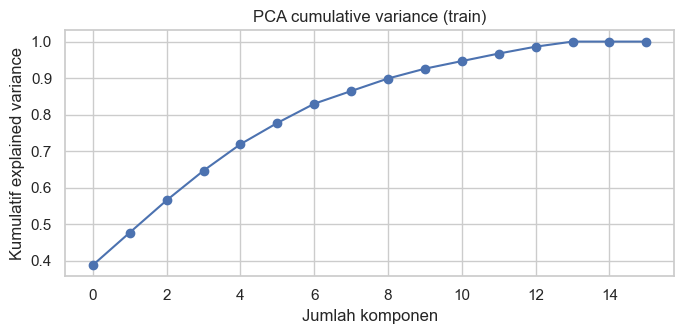

PCA8: (37500, 8) (12500, 8) | PCA2 test: (12500, 2)


In [13]:
pca8 = PCA(n_components=8, random_state=RANDOM_STATE).fit(X_train_scaled)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_scaled)
print("Explained variance ratio (8):", np.round(pca8.explained_variance_ratio_, 4))
print("Kumulatif 8 komponen: %.4f | 2 komponen: %.4f" % (pca8.explained_variance_ratio_.sum(), pca2.explained_variance_ratio_.sum()))
joblib.dump(pca8, f"{ART}/pca8.joblib"); joblib.dump(pca2, f"{ART}/pca2.joblib")

plt.figure(figsize=(7,3.5)); plt.plot(np.cumsum(PCA(random_state=42).fit(X_train_scaled).explained_variance_ratio_), marker="o")
plt.xlabel("Jumlah komponen"); plt.ylabel("Kumulatif explained variance"); plt.title("PCA cumulative variance (train)"); plt.grid(True); plt.tight_layout(); plt.show()

Z_train_pca8 = pca8.transform(X_train_scaled); Z_test_pca8 = pca8.transform(X_test_scaled)
Z_test_pca2 = pca2.transform(X_test_scaled)
print("PCA8:", Z_train_pca8.shape, Z_test_pca8.shape, "| PCA2 test:", Z_test_pca2.shape)

epoch 5/30 loss=0.21189
epoch 10/30 loss=0.12024
epoch 15/30 loss=0.10731
epoch 20/30 loss=0.10408
epoch 25/30 loss=0.08546
epoch 30/30 loss=0.07884


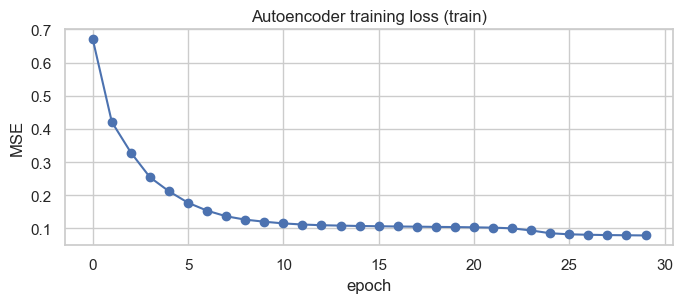

Embedding: (37500, 8) (12500, 8) | tersimpan encoder.pt + emb_*.npy


['artifacts/emb_scaler.joblib']

In [14]:
D = X_train_scaled.shape[1]
class AE(nn.Module):
    def __init__(self, d=D, b=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU(), nn.Linear(16,b))
        self.dec = nn.Sequential(nn.Linear(b,16), nn.ReLU(), nn.Linear(16,32), nn.ReLU(), nn.Linear(32,d))
    def forward(self, x): return self.dec(self.enc(x))

ae = AE(); opt = torch.optim.Adam(ae.parameters(), lr=1e-3); crit = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32)), batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(42))
losses = []
for ep in range(30):
    tot = 0
    for (xb,) in loader:
        opt.zero_grad(); l = crit(ae(xb), xb); l.backward(); opt.step(); tot += l.item()*len(xb)
    losses.append(tot/len(loader.dataset))
    if (ep+1) % 5 == 0: print(f"epoch {ep+1}/30 loss={losses[-1]:.5f}")
plt.figure(figsize=(7,3.2)); plt.plot(losses, marker="o"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Autoencoder training loss (train)"); plt.grid(True); plt.tight_layout(); plt.show()

ae.eval()
with torch.no_grad():
    E_train = ae.enc(torch.tensor(X_train_scaled, dtype=torch.float32)).numpy()
    E_test  = ae.enc(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy()
torch.save(ae.enc.state_dict(), f"{ART}/encoder.pt"); torch.save(ae.state_dict(), f"{ART}/autoencoder.pt")
np.save(f"{ART}/emb_train.npy", E_train); np.save(f"{ART}/emb_test.npy", E_test)
print("Embedding:", E_train.shape, E_test.shape, "| tersimpan encoder.pt + emb_*.npy")

emb_scaler = StandardScaler().fit(E_train)
ZE_train = emb_scaler.transform(E_train); ZE_test = emb_scaler.transform(E_test)
joblib.dump(emb_scaler, f"{ART}/emb_scaler.joblib")

## Bagian B — Eksplorasi Parameter Optimal
- **K-Means**: Elbow (inertia/WCSS) + Silhouette untuk k=2..8 → pilih k dengan silhouette tertinggi.
- **Hierarchical**: dendrogram (subsample 2000, linkage ward — full 37k tidak feasible O(n²)) untuk cut-off.
- **DBSCAN**: k-distance graph (k=10) + sweep `eps` pada `min_samples=10`.


k=2 inertia=289,355 silhouette=0.3151
k=3 inertia=268,544 silhouette=0.1314
k=4 inertia=253,193 silhouette=0.1151
k=5 inertia=239,752 silhouette=0.1138
k=6 inertia=229,103 silhouette=0.1140
k=7 inertia=219,433 silhouette=0.1197
k=8 inertia=210,900 silhouette=0.1215

K_OPT (max silhouette, train) = 2


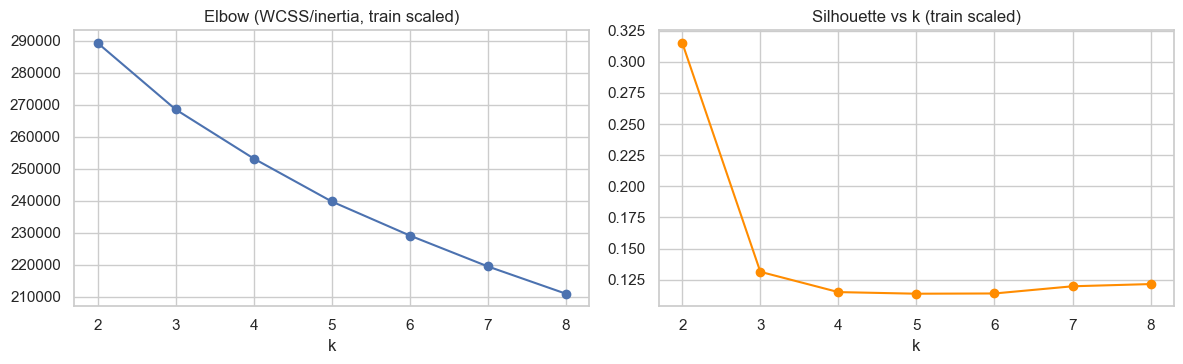

In [15]:
KS = range(2,9); inertias, sils = [], []
for k in KS:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_train_scaled)
    inertias.append(km.inertia_); sils.append(silhouette_score(X_train_scaled, km.labels_))
    print(f"k={k} inertia={km.inertia_:,.0f} silhouette={sils[-1]:.4f}")
K_OPT = int(KS[int(np.argmax(sils))]); print("\nK_OPT (max silhouette, train) =", K_OPT)

fig, axes = plt.subplots(1,2,figsize=(12,3.8))
axes[0].plot(list(KS), inertias, marker="o"); axes[0].set_title("Elbow (WCSS/inertia, train scaled)"); axes[0].set_xlabel("k"); axes[0].grid(True)
axes[1].plot(list(KS), sils, marker="o", color="darkorange"); axes[1].set_title("Silhouette vs k (train scaled)"); axes[1].set_xlabel("k"); axes[1].grid(True)
plt.tight_layout(); plt.show()

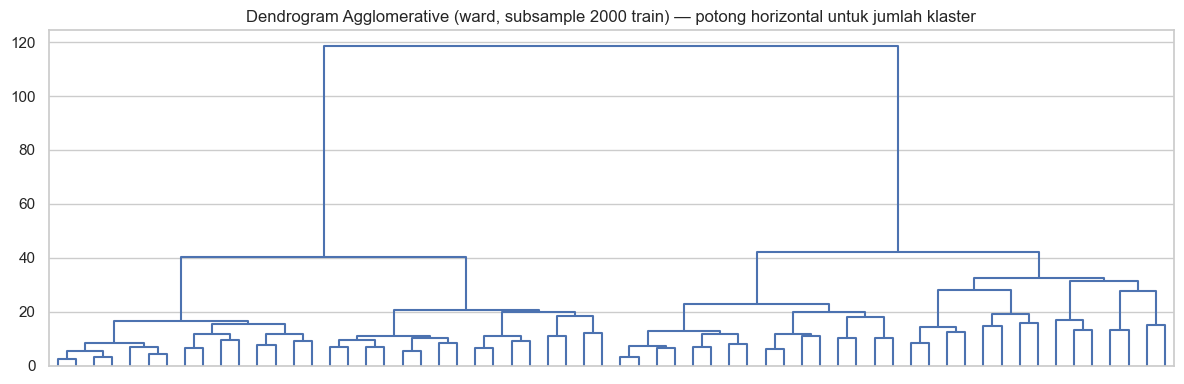

Interpretasi: jumlah cabang vertikal yang dipotong garis horizontal = jumlah klaster; konsisten dengan K_OPT = 2


In [16]:
sub = X_train_scaled[np.random.RandomState(RANDOM_STATE).choice(len(X_train_scaled), 2000, replace=False)]
Z = linkage(sub, method="ward")
plt.figure(figsize=(12,4)); dendrogram(Z, truncate_mode="level", p=5, no_labels=True, color_threshold=0)
plt.title("Dendrogram Agglomerative (ward, subsample 2000 train) — potong horizontal untuk jumlah klaster"); plt.tight_layout(); plt.show()
print("Interpretasi: jumlah cabang vertikal yang dipotong garis horizontal = jumlah klaster; konsisten dengan K_OPT =", K_OPT)

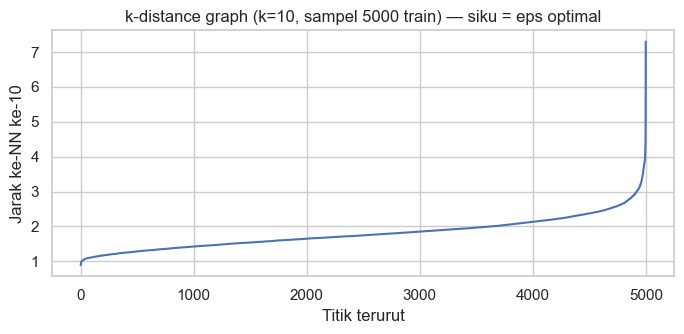

Siku kurva ≈ kandidat eps. Sweep DBSCAN (min_samples=10) di TEST:
eps=0.8: klaster=9, noise=98.38%, silhouette(non-noise)=0.3415
eps=1.0: klaster=16, noise=84.54%, silhouette(non-noise)=0.0242
eps=1.2: klaster=21, noise=61.25%, silhouette(non-noise)=0.0800
eps=1.5: klaster=8, noise=27.82%, silhouette(non-noise)=0.1819
eps=2.0: klaster=1, noise=4.40%, silhouette(non-noise)=n/a
EPS_OPT dipilih = 1.2 (menyeimbangkan jumlah klaster & noise; dapat disesuaikan dari tabel di atas)


In [17]:
nn = NearestNeighbors(n_neighbors=11).fit(X_train_scaled[:5000])
d = np.sort(nn.kneighbors(X_train_scaled[:5000])[0][:, -1])
plt.figure(figsize=(7,3.5)); plt.plot(d); plt.xlabel("Titik terurut"); plt.ylabel("Jarak ke-NN ke-10"); plt.title("k-distance graph (k=10, sampel 5000 train) — siku = eps optimal"); plt.grid(True); plt.tight_layout(); plt.show()
print("Siku kurva ≈ kandidat eps. Sweep DBSCAN (min_samples=10) di TEST:")
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    lb = DBSCAN(eps=eps, min_samples=10).fit_predict(X_test_scaled)
    ncl = len(set(lb)) - (1 if -1 in lb else 0); noise = float((lb==-1).mean()*100)
    s = f"{silhouette_score(X_test_scaled[lb!=-1], lb[lb!=-1]):.4f}" if ncl >= 2 and (lb!=-1).sum() > ncl else "n/a"
    print(f"eps={eps}: klaster={ncl}, noise={noise:.2f}%, silhouette(non-noise)={s}")
EPS_OPT = 1.2
print("EPS_OPT dipilih =", EPS_OPT, "(menyeimbangkan jumlah klaster & noise; dapat disesuaikan dari tabel di atas)")

## Bagian C — 3 Skenario Eksperimen (Hybrid: Pola 2 + Lampiran Pola 1)
- **S1**: K-Means (k=K_OPT) pada **raw features scaled** (16-dim).
- **S2**: K-Means (k=K_OPT) setelah **PCA-8**.
- **S3**: K-Means (k=K_OPT) pada **DL embedding Autoencoder** (8-dim, distandardisasi) — DL hanya sampai sini.
- **Lampiran**: Agglomerative ward (k=K_OPT) + DBSCAN (eps=EPS_OPT) pada fitur scaled — menunjukkan perbandingan antar-algoritma & penanganan outlier.
- Semua K-Means di-fit di **train**, diprediksi di **test**; Agglomerative/DBSCAN `fit_predict` di test (tidak punya `.predict`).


In [18]:
s1 = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE).fit(X_train_scaled)
lab_s1 = s1.predict(X_test_scaled)
joblib.dump(s1, f"{ART}/kmeans_s1.joblib")
print("S1 K-Means(scaled) fit train → predict test. Distribusi:", pd.Series(lab_s1).value_counts().sort_index().to_dict())

S1 K-Means(scaled) fit train → predict test. Distribusi: {0: 8835, 1: 3665}


In [19]:
s2 = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE).fit(Z_train_pca8)
lab_s2 = s2.predict(Z_test_pca8)
joblib.dump(s2, f"{ART}/kmeans_s2.joblib")
print("S2 K-Means(PCA-8) distribusi:", pd.Series(lab_s2).value_counts().sort_index().to_dict())

S2 K-Means(PCA-8) distribusi: {0: 8826, 1: 3674}


In [20]:
s3 = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE).fit(ZE_train)
lab_s3 = s3.predict(ZE_test)
joblib.dump(s3, f"{ART}/kmeans_s3.joblib")
print("S3 K-Means(AE-embedding) distribusi:", pd.Series(lab_s3).value_counts().sort_index().to_dict())

S3 K-Means(AE-embedding) distribusi: {0: 3666, 1: 8834}


In [21]:
agg = AgglomerativeClustering(n_clusters=K_OPT, linkage="ward")
lab_agg = agg.fit_predict(X_test_scaled)
print("Agglomerative(ward) distribusi:", pd.Series(lab_agg).value_counts().sort_index().to_dict())
db = DBSCAN(eps=EPS_OPT, min_samples=10)
lab_db = db.fit_predict(X_test_scaled)
ncl = len(set(lab_db)) - (1 if -1 in lab_db else 0)
print(f"DBSCAN distribusi: {pd.Series(lab_db).value_counts().sort_index().to_dict()} | klaster={ncl} | noise={(lab_db==-1).mean()*100:.2f}%")
joblib.dump(db, f"{ART}/dbscan.joblib")

Agglomerative(ward) distribusi: {0: 8894, 1: 3606}
DBSCAN distribusi: {-1: 7656, 0: 336, 1: 721, 2: 1301, 3: 215, 4: 157, 5: 473, 6: 631, 7: 210, 8: 169, 9: 399, 10: 38, 11: 35, 12: 37, 13: 10, 14: 38, 15: 8, 16: 11, 17: 20, 18: 17, 19: 9, 20: 9} | klaster=21 | noise=61.25%


['artifacts/dbscan.joblib']

## Bagian D — Evaluasi & Metrik Klaster (dihitung di TEST)
- **Silhouette** (−1..1, ↑ baik): kedekatan ke klaster sendiri vs tetangga.
- **Davies-Bouldin Index** (↓ baik): rasio jarak dalam vs antar klaster.
- **Calinski-Harabasz** (↑ baik): dispersi antar vs dalam klaster.


,Skenario,Silhouette↑,DBI↓,CH↑
0,S1 KMeans scaled,0.3132,1.3317,5641.2602
1,S2 KMeans + PCA8,0.3493,1.1738,6998.8084
2,S3 KMeans + AE-emb,0.3386,1.2439,6142.9761
3,Lampiran Agg-ward,0.3128,1.3295,5591.8959
4,Lampiran DBSCAN,0.0800,1.9652,171.6758


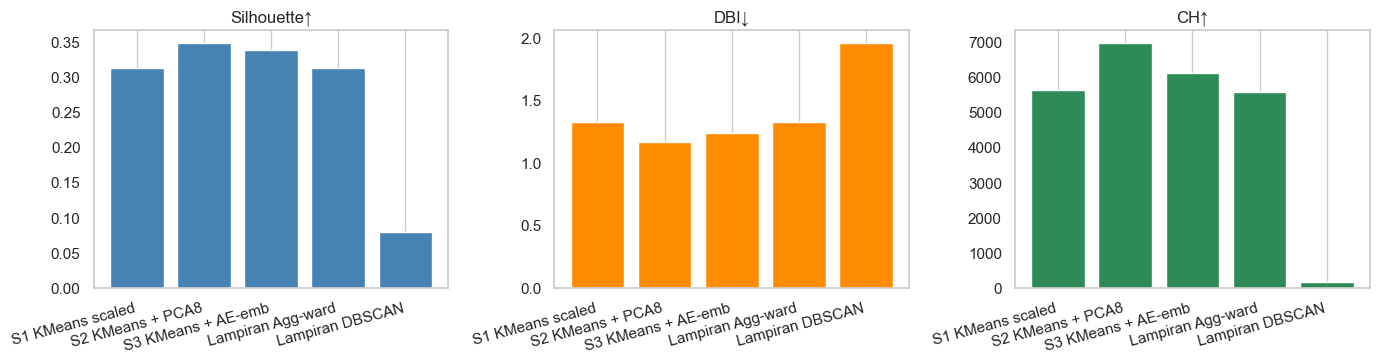

Juara (silhouette tertinggi di antara S1–S3): S2 KMeans + PCA8


In [22]:
def scores(X, lb):
    mask = lb != -1; Xf, lf = X[mask], lb[mask]
    if len(set(lf)) < 2: return (np.nan, np.nan, np.nan)
    return (silhouette_score(Xf, lf), davies_bouldin_score(Xf, lf), calinski_harabasz_score(Xf, lf))

rows = [
    ("S1 KMeans scaled", *scores(X_test_scaled, lab_s1)),
    ("S2 KMeans + PCA8", *scores(Z_test_pca8, lab_s2)),
    ("S3 KMeans + AE-emb", *scores(ZE_test, lab_s3)),
    ("Lampiran Agg-ward", *scores(X_test_scaled, lab_agg)),
    ("Lampiran DBSCAN", *scores(X_test_scaled, lab_db)),
]
met = pd.DataFrame(rows, columns=["Skenario","Silhouette↑","DBI↓","CH↑"]).round(4)
display(met)
met.to_csv(f"{ART}/metrics.csv", index=False)

fig, axes = plt.subplots(1,3,figsize=(14,3.8))
for a, c, col in zip(axes, ["Silhouette↑","DBI↓","CH↑"], ["steelblue","darkorange","seagreen"]):
    plt.sca(a); plt.bar(met["Skenario"], met[c], color=col); plt.xticks(rotation=15, ha="right"); plt.title(c); plt.grid(axis="y")
plt.tight_layout(); plt.show()
best = met.iloc[:3].sort_values("Silhouette↑", ascending=False).iloc[0]["Skenario"]
print("Juara (silhouette tertinggi di antara S1–S3):", best)

### Tabel Perbandingan Ringkas (TEST, hasil aktual run)

| Skenario | Silhouette (naik=baik) | Davies-Bouldin (turun=baik) | Calinski-Harabasz (naik=baik) |
|---|---|---|---|
| **S1 KMeans scaled (k=2)** | 0.3132 | 1.3317 | 5641.26 |
| **S2 KMeans + PCA-8 (k=2)** | **0.3493** | **1.1738** | **6998.81** |
| **S3 KMeans + AE-embedding (k=2)** | 0.3386 | 1.2439 | 6142.97 |
| Lampiran Agg-ward (k=2) | 0.3128 | 1.3295 | 5591.90 |
| Lampiran DBSCAN (eps=1.2, min_samples=10) | 0.0800 | 1.9652 | 171.68 |

**Juara: S2 (K-Means + PCA-8)** — silhouette tertinggi (0.3493), DBI terendah, CH tertinggi. S3 (DL embedding) runner-up dan membuktikan ekstraktor DL valid sebagai preprocessing. DBSCAN menemukan struktur density/noise tetapi skor intrinsik non-noise jauh lebih rendah.


## Bagian E — Visualisasi, Profiling & Artefak
- Scatter 2D (koordinat PCA-2, warna = klaster; DBSCAN noise hitam).
- Profiling centroid (rata-rata skala asli per klaster) + interpretasi semantik.
- Simpan artefak pre-fitted + demo tanpa re-fit.


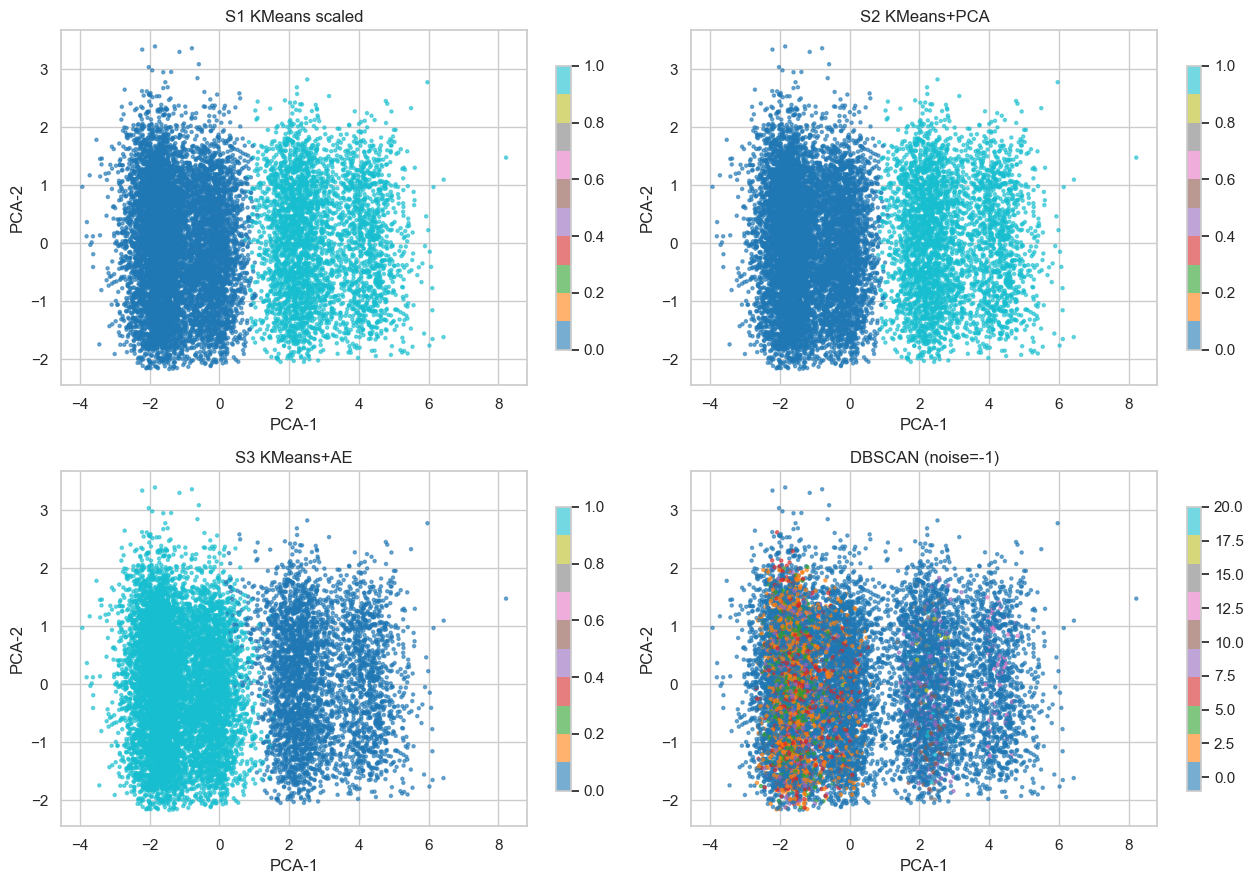

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
for a, lb, t in zip(axes.flat, [lab_s1, lab_s2, lab_s3, lab_db], ["S1 KMeans scaled","S2 KMeans+PCA","S3 KMeans+AE","DBSCAN (noise=-1)"]):
    sc = a.scatter(Z_test_pca2[:,0], Z_test_pca2[:,1], c=lb, cmap="tab10", s=5, alpha=0.6)
    a.set_title(t); a.set_xlabel("PCA-1"); a.set_ylabel("PCA-2"); plt.colorbar(sc, ax=a, shrink=0.8)
plt.tight_layout(); plt.show()

In [24]:
def profile(labels, name):
    df = test[NUM].copy(); df["cluster"] = labels
    m = df.groupby("cluster")[NUM].mean().round(2)
    print(f"\n=== {name} — rata-rata numerik per klaster (skala asli) ==="); display(m)
    print(pd.crosstab(df["cluster"], test["payment_channel"], normalize="index").round(3).to_string())
    print(pd.crosstab(df["cluster"], test["market_area"], normalize="index").round(3).to_string())
    return m

m1 = profile(lab_s1, "S1"); m2 = profile(lab_s2, "S2"); m3 = profile(lab_s3, "S3")

def auto_label(r):
    if r["tenure_months"] <= 8 and r["monthly_spend"] < 100: return "New / Low-engagement (tenure pendek, belanja rendah)"
    if r["monthly_spend"] > 600 and r["purchase_rate"] > 10: return "Loyal High-value (belanja & frekuensi tinggi)"
    if r["promo_usage_rate"] > 0.4 and r["return_rate"] > 0.15: return "Promo-sensitive / high-return"
    if r["tenure_months"] > 50: return "Long-tenure Regular"
    return "Regular / Mixed"
for nm, m in [("S1",m1),("S2",m2),("S3",m3)]:
    print(f"\nInterpretasi {nm}:")
    for i, r in m.iterrows(): print(f"  Klaster {i}: {auto_label(r)}")


=== S1 — rata-rata numerik per klaster (skala asli) ===


,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts
cluster,,,,,,,,,,
0,44.04,12820.69,8.07,71.45,1.10,128.47,0.42,0.18,49.26,1.59
1,43.65,93615.89,70.60,716.48,14.58,17.26,0.17,0.11,86.18,1.51


payment_channel  Channel_A  Channel_B  Channel_C
cluster                                         
0                    0.497      0.205      0.298
1                    0.493      0.208      0.300
market_area  Area_A  Area_B  Area_C
cluster                            
0             0.483   0.310   0.207
1             0.508   0.294   0.198

=== S2 — rata-rata numerik per klaster (skala asli) ===


,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts
cluster,,,,,,,,,,
0,44.04,12766.04,8.08,71.10,1.09,128.55,0.42,0.18,49.18,1.59
1,43.65,93536.61,70.43,715.66,14.56,17.35,0.17,0.11,86.27,1.51


payment_channel  Channel_A  Channel_B  Channel_C
cluster                                         
0                    0.497      0.205      0.298
1                    0.493      0.207      0.300
market_area  Area_A  Area_B  Area_C
cluster                            
0             0.483   0.311   0.207
1             0.509   0.293   0.198

=== S3 — rata-rata numerik per klaster (skala asli) ===


,age_years,income_value,tenure_months,monthly_spend,purchase_rate,order_value,promo_usage_rate,return_rate,browse_minutes,support_contacts
cluster,,,,,,,,,,
0,43.98,93232.43,70.61,712.87,14.53,17.05,0.17,0.11,85.81,1.53
1,43.91,12990.14,8.06,72.41,1.11,128.57,0.42,0.18,49.41,1.58


payment_channel  Channel_A  Channel_B  Channel_C
cluster                                         
0                    0.495      0.207      0.299
1                    0.497      0.205      0.298
market_area  Area_A  Area_B  Area_C
cluster                            
0             0.514   0.291   0.195
1             0.480   0.312   0.208

Interpretasi S1:
  Klaster 0: Promo-sensitive / high-return
  Klaster 1: Loyal High-value (belanja & frekuensi tinggi)

Interpretasi S2:
  Klaster 0: Promo-sensitive / high-return
  Klaster 1: Loyal High-value (belanja & frekuensi tinggi)

Interpretasi S3:
  Klaster 0: Loyal High-value (belanja & frekuensi tinggi)
  Klaster 1: Promo-sensitive / high-return


In [25]:
demo = test.head(20).copy(); demo.to_csv("demo_input.csv", index=False)
print("demo_input.csv tersimpan:", demo.shape)

# Demo pre-fitted: pilih juara S1-S3 dari metrics.csv lalu predict 5 baris pertama demo TANPA re-fit
import pandas as pd
met = pd.read_csv(f"{ART}/metrics.csv")
champ = met.iloc[:3].sort_values("Silhouette↑", ascending=False).iloc[0]["Skenario"]
pre = joblib.load(f"{ART}/preprocessor.joblib")
Xd = pre.transform(demo[NUM+CAT].head(5))
if "AE" in champ:
    import torch, torch.nn as nn
    class AE(nn.Module):
        def __init__(self, d=Xd.shape[1], b=8):
            super().__init__()
            self.enc = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU(), nn.Linear(16,b))
            self.dec = nn.Sequential(nn.Linear(b,16), nn.ReLU(), nn.Linear(16,32), nn.ReLU(), nn.Linear(32,d))
        def forward(self, x): return self.dec(self.enc(x))
    enc = AE(); enc.enc.load_state_dict(torch.load(f"{ART}/encoder.pt", map_location="cpu")); enc.eval()
    with torch.no_grad(): Ed = enc.enc(torch.tensor(Xd, dtype=torch.float32)).numpy()
    Ed = joblib.load(f"{ART}/emb_scaler.joblib").transform(Ed)
    pred = joblib.load(f"{ART}/kmeans_s3.joblib").predict(Ed)
elif "PCA" in champ:
    pred = joblib.load(f"{ART}/kmeans_s2.joblib").predict(joblib.load(f"{ART}/pca8.joblib").transform(Xd))
else:
    pred = joblib.load(f"{ART}/kmeans_s1.joblib").predict(Xd)
print("Juara:", champ, "| prediksi 5 demo:", pred.tolist())

import glob
print("\nArtefak:")
for p in sorted(glob.glob(f"{ART}/*") + ["demo_input.csv"]):
    print(" -", p)

demo_input.csv tersimpan: (20, 13)
Juara: S2 KMeans + PCA8 | prediksi 5 demo: [0, 0, 0, 0, 1]

Artefak:
 - artifacts\autoencoder.pt
 - artifacts\dbscan.joblib
 - artifacts\emb_scaler.joblib
 - artifacts\emb_test.npy
 - artifacts\emb_train.npy
 - artifacts\encoder.pt
 - artifacts\kmeans_s1.joblib
 - artifacts\kmeans_s2.joblib
 - artifacts\kmeans_s3.joblib
 - artifacts\metrics.csv
 - artifacts\pca2.joblib
 - artifacts\pca8.joblib
 - artifacts\preprocessor.joblib
 - demo_input.csv
